In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from statsmodels.regression.linear_model import OLS
from functions import *

In [2]:
#Read in data file (see data_processing.ipynb for how this file is generated)
#Keep only Lec, CG, WG, and SQ codes (see paper for discussion of feature selection)
codes_and_CIs = pd.read_csv('Published Data/combined_COPUS_CI_data.csv')
measured_data = pd.read_csv('Measured Data/measured_data.csv')
measured_data = measured_data[measured_data['PreMean'] < .6]
#concat 
codes_and_CIs = pd.concat([codes_and_CIs, measured_data], axis=0, ignore_index=True)

#The target variable is the effect size
target = codes_and_CIs['Effect Size'].to_numpy()

In [3]:
    ##plotting LOO predictions with error bars representing uncertainty across different fits
def LOO_plot(target, LOO_predictions_mean, LOO_predictions_std):
    x, y = target, LOO_predictions_mean
    plt.plot([np.min(x), np.max(x)], [np.min(x), np.max(x)], 'k--', alpha=.5)

    where_low_error = np.where(LOO_predictions_std < .3)
    where_high_error = np.where(LOO_predictions_std >= .3)
    low_x, low_y = x[where_low_error], y[where_low_error]
    high_x, high_y = x[where_high_error], y[where_high_error]

    m, b = np.polyfit(x, y, 1)
    xi = np.linspace(np.min(x), np.max(x), 100)


    plt.scatter(low_x, low_y, label='Prediction uncertainty < .3', color='blue', alpha=0.7)
    plt.errorbar(low_x, low_y, yerr=LOO_predictions_std[where_low_error], fmt='o', color='blue', alpha=0.5)

    plt.scatter(high_x, high_y, label='Prediction uncertainty > .3', color='red', alpha=0.7)
    plt.errorbar(high_x, high_y, yerr=LOO_predictions_std[where_high_error], fmt='o', color='red', alpha=0.5)

    plt.xlabel(f'Measured Effect Size')
    plt.ylabel(f'Predicted Effect Size')
    plt.ylim(0, 3)
    #plt.title(f'Leave-One-Out Predictions vs Target')
    plt.legend()
    plt.savefig('Figs/LOO.png', dpi=300)
    plt.show()

    print(f'R^2: {np.corrcoef(x, y)[0, 1]**2:.3f}')
    print(f'Mean absolute error: {np.mean(np.abs(y-x)):.4f}')
    print('-----')
    print(f'R^2 removing high uncertainty: {np.corrcoef(low_x, low_y)[0, 1]**2:.3f}')
    print(f'MAE removing high uncertainty: {np.mean(np.abs(low_y-low_x)):.4f}')



Iteration 1 finished with AIC 94.11
Iteration 1001 finished with AIC 96.75
Iteration 2001 finished with AIC 108.2
Iteration 3001 finished with AIC 105.77
Iteration 4001 finished with AIC 109.78
Iteration 5001 finished with AIC 56.0
Iteration 6001 finished with AIC 96.28
Iteration 7001 finished with AIC 97.65
Iteration 8001 finished with AIC 169.16
Iteration 9001 finished with AIC 70.7


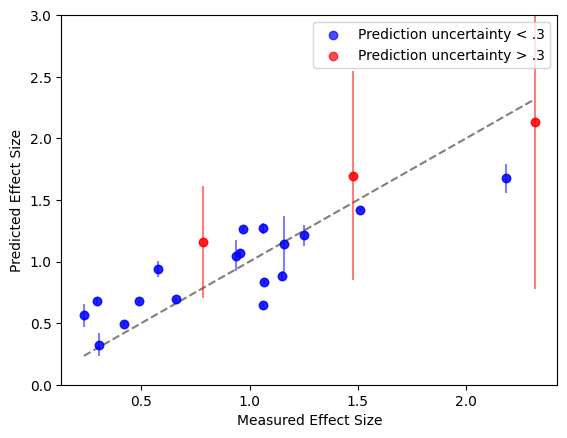

R^2: 0.797
Mean absolute error: 0.2124
-----
R^2 removing high uncertainty: 0.742
MAE removing high uncertainty: 0.2049


In [4]:
sundstrom_data = pd.read_csv('Published Data/sundstrom_COPUS_CI.csv')

repeat_institutions = ['ISLE_Course3', 'ISLE_Course4', 'ISLE_Course1', 'PeerInstruction_Course3', 'PeerInstruction_Course4',]

sundstrom_classes_no_repeat = sundstrom_data[~sundstrom_data['Course'].isin(repeat_institutions)]

no_repeat_index = np.where(codes_and_CIs['Course'].isin(sundstrom_classes_no_repeat['Course']))[0]

#Maximum number of codes, choose CG over CQ

#these will be input features for the model
data = codes_and_CIs[[ 'Lec', 'CG', 'WG',  'OG', 'SQ', ]].to_numpy()
#This is a linear regression model, but we use nonlinear terms by adding polynomila features
data = add_cross_terms(data)
keepers, AICs, good_fits = feature_selection(data, target, its=10000, n =1, prt = True, num_choose = 10)

LOO_predictions_mean, LOO_predictions_std, LOO_weights = bootstrap_LOO(data, target, keepers, good_fits, bootstrap_n=300, leave_out=no_repeat_index)

LOO_plot(target[no_repeat_index], LOO_predictions_mean[no_repeat_index], LOO_predictions_std[no_repeat_index])

### Maximum codes: Lec, CG, WG, OG, SQ

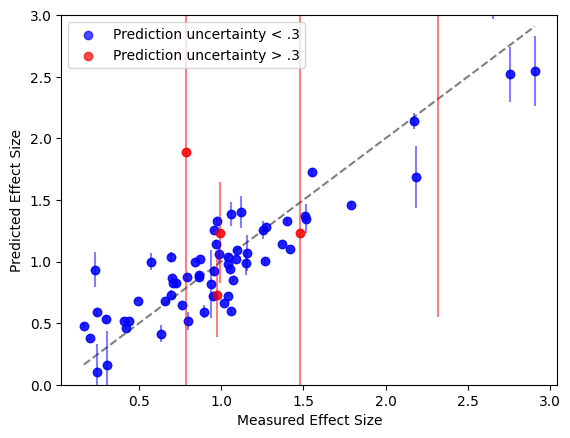

R^2: 0.768
Mean absolute error: 0.2202
-----
R^2 removing high uncertainty: 0.826
MAE removing high uncertainty: 0.1951


In [ ]:
#Maximum number of codes, choose CG over CQ

#these will be input features for the model
data = codes_and_CIs[[ 'Lec', 'CG', 'WG',  'OG', 'SQ', ]].to_numpy()
#This is a linear regression model, but we use nonlinear terms by adding polynomila features
data = add_cross_terms(data)
keepers, AICs, good_fits = feature_selection(data, target, its=10000, n =1, prt = True, num_choose = 10)

LOO_predictions_mean, LOO_predictions_std, LOO_weights = bootstrap_LOO(data, target, keepers, good_fits, bootstrap_n=300)

LOO_plot(target, LOO_predictions_mean, LOO_predictions_std)

## Same but choose CQ over CG

Iteration 1 finished with AIC 55.59
Iteration 1001 finished with AIC 87.52
Iteration 2001 finished with AIC 123.46
Iteration 3001 finished with AIC 152.56
Iteration 4001 finished with AIC 75.07
Iteration 5001 finished with AIC 115.33
Iteration 6001 finished with AIC 94.61
Iteration 7001 finished with AIC 107.47
Iteration 8001 finished with AIC 105.25
Iteration 9001 finished with AIC 180.77


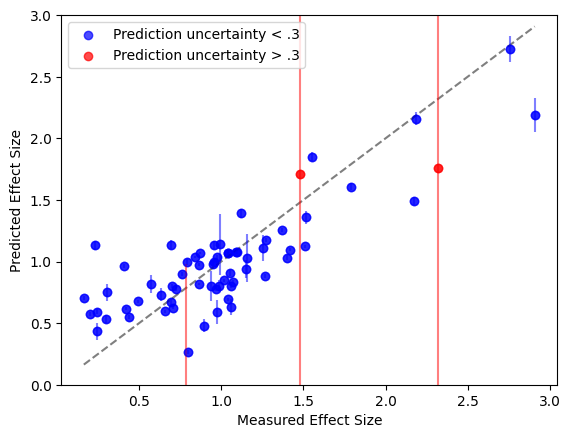

R^2: 0.687
Mean absolute error: 0.2528
-----
R^2 removing high uncertainty: 0.723
MAE removing high uncertainty: 0.2357


In [60]:
#Maximum number of codes, choose CQ over CG
#CG does way better


#these will be input features for the model
data = codes_and_CIs[[ 'Lec', 'CQ', 'WG',  'OG', 'SQ', ]].to_numpy()
#This is a linear regression model, but we use nonlinear terms by adding polynomila features
data = add_cross_terms(data)

keepers, AICs, good_fits = feature_selection(data, target, its=10000, n =1, prt = True, num_choose = 10)

LOO_predictions_mean, LOO_predictions_std, LOO_weights = bootstrap_LOO(data, target, keepers, good_fits, bootstrap_n=300)

LOO_plot(target, LOO_predictions_mean, LOO_predictions_std)

## Replace WG and OG with PQ

PQ necessarily happens alongside WG and OG

Iteration 1 finished with AIC 159.05
Iteration 1001 finished with AIC 128.92
Iteration 2001 finished with AIC 109.41
Iteration 3001 finished with AIC 100.18
Iteration 4001 finished with AIC 124.76
Iteration 5001 finished with AIC 128.3
Iteration 6001 finished with AIC 112.5
Iteration 7001 finished with AIC 108.17
Iteration 8001 finished with AIC 117.77
Iteration 9001 finished with AIC 112.39


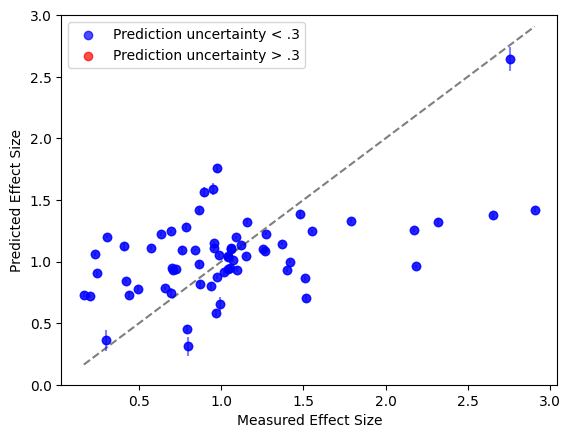

R^2: 0.272
Mean absolute error: 0.3773
-----
R^2 removing high uncertainty: 0.272
MAE removing high uncertainty: 0.3773


In [61]:
#replace OG and WG with PQ
#does way worse

#these will be input features for the model
data = codes_and_CIs[[ 'Lec', 'CG', 'PQ', 'SQ', ]].to_numpy()
#This is a linear regression model, but we use nonlinear terms by adding polynomila features
data = add_cross_terms(data)

keepers, AICs, good_fits = feature_selection(data, target, its=10000, n =1, prt = True, num_choose = 10)

LOO_predictions_mean, LOO_predictions_std, LOO_weights = bootstrap_LOO(data, target, keepers, good_fits, bootstrap_n=300)

LOO_plot(target, LOO_predictions_mean, LOO_predictions_std)

## Remove Lec: CG, WG, OG,  SQ (only student vars)

Iteration 1 finished with AIC 79.05
Iteration 1001 finished with AIC 53.82
Iteration 2001 finished with AIC 98.83
Iteration 3001 finished with AIC 95.66
Iteration 4001 finished with AIC 101.22
Iteration 5001 finished with AIC 79.77
Iteration 6001 finished with AIC 95.72
Iteration 7001 finished with AIC 90.26
Iteration 8001 finished with AIC 103.19
Iteration 9001 finished with AIC 62.7


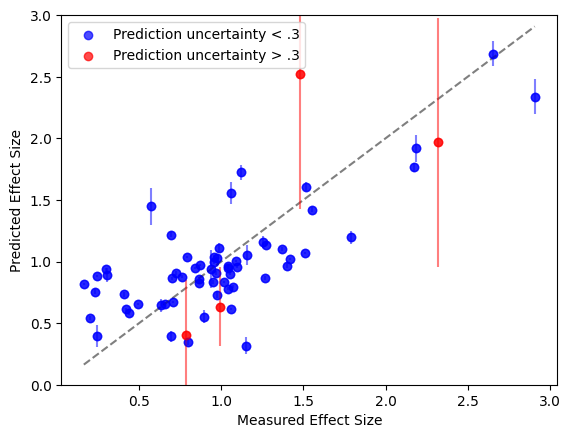

R^2: 0.621
Mean absolute error: 0.2879
-----
R^2 removing high uncertainty: 0.640
MAE removing high uncertainty: 0.2724


In [62]:
#remove lec

#these will be input features for the model
data = codes_and_CIs[[ 'WG', 'CG', 'OG', 'SQ', ]].to_numpy()
#This is a linear regression model, but we use nonlinear terms by adding polynomila features
data = add_cross_terms(data)

keepers, AICs, good_fits = feature_selection(data, target, its=10000, n =1, prt = True, num_choose = 10)

LOO_predictions_mean, LOO_predictions_std, LOO_weights = bootstrap_LOO(data, target, keepers, good_fits, bootstrap_n=300)

LOO_plot(target, LOO_predictions_mean, LOO_predictions_std)

## Remove OG: Lec, CG, WG, SQ (Previous)

Iteration 1 finished with AIC 78.32
Iteration 1001 finished with AIC 35.29
Iteration 2001 finished with AIC 64.24
Iteration 3001 finished with AIC 62.19
Iteration 4001 finished with AIC 55.99
Iteration 5001 finished with AIC 42.5
Iteration 6001 finished with AIC 38.42
Iteration 7001 finished with AIC 94.59
Iteration 8001 finished with AIC 53.31
Iteration 9001 finished with AIC 62.41


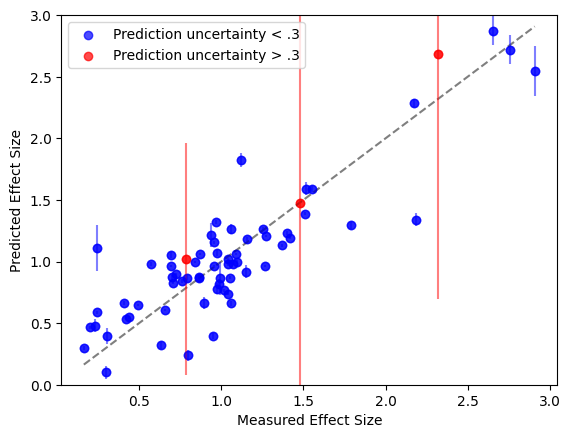

R^2: 0.771
Mean absolute error: 0.2160
-----
R^2 removing high uncertainty: 0.755
MAE removing high uncertainty: 0.2167


In [63]:
#remove OG

#these will be input features for the model
data = codes_and_CIs[[ 'Lec', 'CG', 'WG', 'SQ', ]].to_numpy()
#This is a linear regression model, but we use nonlinear terms by adding polynomila features
data = add_cross_terms(data)

keepers, AICs, good_fits = feature_selection(data, target, its=10000, n =1, prt = True, num_choose = 10)

LOO_predictions_mean, LOO_predictions_std, LOO_weights = bootstrap_LOO(data, target, keepers, good_fits, bootstrap_n=300)

LOO_plot(target, LOO_predictions_mean, LOO_predictions_std)

## Remove WG: Lec, CG, OG, SQ

Iteration 1 finished with AIC 125.16
Iteration 1001 finished with AIC 122.02
Iteration 2001 finished with AIC 129.95
Iteration 3001 finished with AIC 105.68
Iteration 4001 finished with AIC 118.71
Iteration 5001 finished with AIC 116.97
Iteration 6001 finished with AIC 127.25
Iteration 7001 finished with AIC 133.93
Iteration 8001 finished with AIC 135.95
Iteration 9001 finished with AIC 123.13


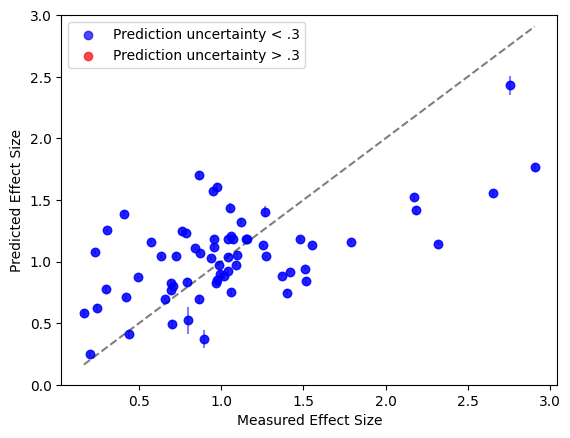

R^2: 0.360
Mean absolute error: 0.3613
-----
R^2 removing high uncertainty: 0.360
MAE removing high uncertainty: 0.3613


In [64]:
#remove WG

#these will be input features for the model
data = codes_and_CIs[[ 'Lec', 'CG', 'OG', 'SQ', ]].to_numpy()
#This is a linear regression model, but we use nonlinear terms by adding polynomila features
data = add_cross_terms(data)

keepers, AICs, good_fits = feature_selection(data, target, its=10000, n =1, prt = True, num_choose = 10)

LOO_predictions_mean, LOO_predictions_std, LOO_weights = bootstrap_LOO(data, target, keepers, good_fits, bootstrap_n=300)

LOO_plot(target, LOO_predictions_mean, LOO_predictions_std)

## Remove SQ: Lec, CG, WG, OG

Iteration 1 finished with AIC 79.32
Iteration 1001 finished with AIC 62.54
Iteration 2001 finished with AIC 121.13
Iteration 3001 finished with AIC 92.91
Iteration 4001 finished with AIC 77.1
Iteration 5001 finished with AIC 92.25
Iteration 6001 finished with AIC 90.37
Iteration 7001 finished with AIC 128.09
Iteration 8001 finished with AIC 85.77
Iteration 9001 finished with AIC 81.05


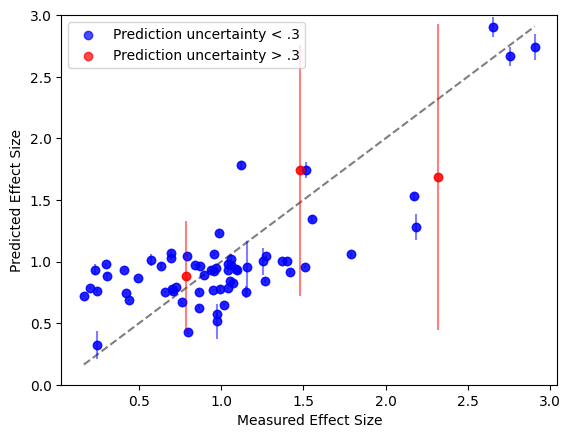

R^2: 0.616
Mean absolute error: 0.2956
-----
R^2 removing high uncertainty: 0.603
MAE removing high uncertainty: 0.2940


In [65]:
#remove SQ

#these will be input features for the model
data = codes_and_CIs[[ 'Lec', 'CG', 'WG', 'OG',  ]].to_numpy()
#This is a linear regression model, but we use nonlinear terms by adding polynomila features
data = add_cross_terms(data)

keepers, AICs, good_fits = feature_selection(data, target, its=10000, n =1, prt = True, num_choose = 10)

LOO_predictions_mean, LOO_predictions_std, LOO_weights = bootstrap_LOO(data, target, keepers, good_fits, bootstrap_n=300)

LOO_plot(target, LOO_predictions_mean, LOO_predictions_std)

## Combine WG and OG

Iteration 1 finished with AIC 118.92
Iteration 1001 finished with AIC 93.28
Iteration 2001 finished with AIC 122.86
Iteration 3001 finished with AIC 117.15
Iteration 4001 finished with AIC 130.2
Iteration 5001 finished with AIC 101.61
Iteration 6001 finished with AIC 91.2
Iteration 7001 finished with AIC 111.61
Iteration 8001 finished with AIC 108.43
Iteration 9001 finished with AIC 104.43


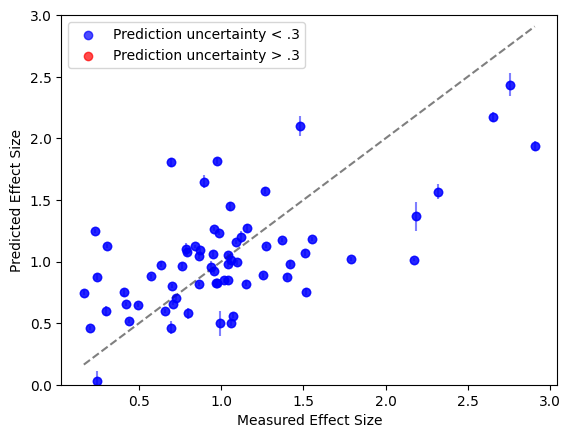

R^2: 0.400
Mean absolute error: 0.3548
-----
R^2 removing high uncertainty: 0.400
MAE removing high uncertainty: 0.3548


In [76]:
#combine WG and OG

#these will be input features for the model
data = codes_and_CIs[[ 'Lec', 'CG', 'WG', 'OG', 'SQ' ]].to_numpy()
data[:, 2] = data[:, 2] + data[:, 3]
data = data[:, [0, 1, 2, 4]] #remove OG
#This is a linear regression model, but we use nonlinear terms by adding polynomila features
data = add_cross_terms(data)

keepers, AICs, good_fits = feature_selection(data, target, its=10000, n =1, prt = True, num_choose = 10)

LOO_predictions_mean, LOO_predictions_std, LOO_weights = bootstrap_LOO(data, target, keepers, good_fits, bootstrap_n=300)

LOO_plot(target, LOO_predictions_mean, LOO_predictions_std)

Iteration 1 finished with AIC 75.98
Iteration 1001 finished with AIC 114.42
Iteration 2001 finished with AIC 89.59
Iteration 3001 finished with AIC 95.88
Iteration 4001 finished with AIC 102.58
Iteration 5001 finished with AIC 82.04
Iteration 6001 finished with AIC 124.26
Iteration 7001 finished with AIC 118.1
Iteration 8001 finished with AIC 129.58
Iteration 9001 finished with AIC 117.28


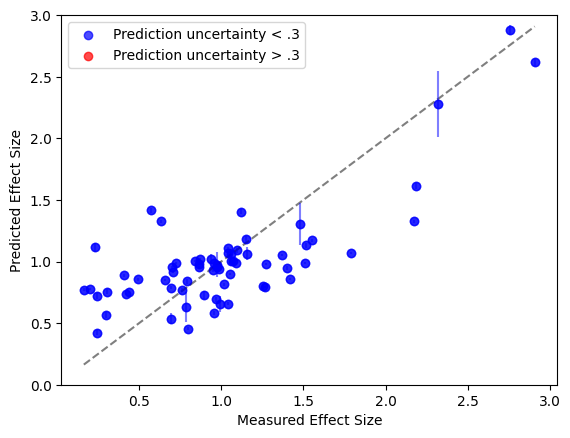

R^2: 0.630
Mean absolute error: 0.2764
-----
R^2 removing high uncertainty: 0.630
MAE removing high uncertainty: 0.2764


In [78]:
#combine CG and OG

#these will be input features for the model
data = codes_and_CIs[[ 'Lec', 'CG', 'WG', 'OG', 'SQ' ]].to_numpy()
data[:, 1] = data[:, 1] + data[:, 3]
data = data[:, [0, 1, 2, 4]] #remove OG
#This is a linear regression model, but we use nonlinear terms by adding polynomila features
data = add_cross_terms(data)

keepers, AICs, good_fits = feature_selection(data, target, its=10000, n =1, prt = True, num_choose = 10)

LOO_predictions_mean, LOO_predictions_std, LOO_weights = bootstrap_LOO(data, target, keepers, good_fits, bootstrap_n=300)

LOO_plot(target, LOO_predictions_mean, LOO_predictions_std)

## Combine all group work

Iteration 1 finished with AIC 109.29
Iteration 1001 finished with AIC 95.1
Iteration 2001 finished with AIC 97.74
Iteration 3001 finished with AIC 93.93
Iteration 4001 finished with AIC 96.96
Iteration 5001 finished with AIC 108.59
Iteration 6001 finished with AIC 102.9
Iteration 7001 finished with AIC 119.38
Iteration 8001 finished with AIC 89.34
Iteration 9001 finished with AIC 83.01


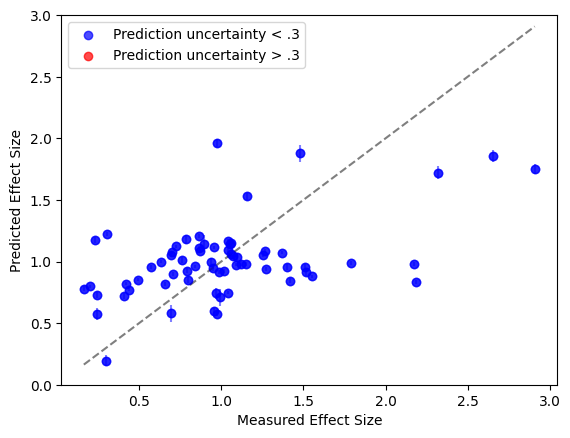

R^2: 0.355
Mean absolute error: 0.3669
-----
R^2 removing high uncertainty: 0.355
MAE removing high uncertainty: 0.3669


In [77]:
#combine all group work

#combine WG and OG

#these will be input features for the model
data = codes_and_CIs[[ 'Lec', 'CG', 'WG', 'OG', 'SQ' ]].to_numpy()
data[:, 2] = data[:, 2] + data[:, 3] + data[:, 1]
data = data[:, [0,  2, 4]] #remove OG
#This is a linear regression model, but we use nonlinear terms by adding polynomila features
data = add_cross_terms(data)

keepers, AICs, good_fits = feature_selection(data, target, its=10000, n =1, prt = True, num_choose = 10)

LOO_predictions_mean, LOO_predictions_std, LOO_weights = bootstrap_LOO(data, target, keepers, good_fits, bootstrap_n=300)

LOO_plot(target, LOO_predictions_mean, LOO_predictions_std)

# Model Complexity

In [66]:
#up to third order terms

def add_cross_terms_3(data):
    ## this functions adds polynomial and cross terms to the data
        
    pts, features = data.shape
    #
    cross_factors = (data[:, :features].reshape(pts, 1, features) *data[:, :features].reshape(pts, features, 1))#.reshape(pts, features * features)
    #keep only upper triangle

    #second order terms
    cross_factors = cross_factors[:, np.triu_indices(features, k=1)[0], np.triu_indices(features, k=1)[1]]
    cross_factors = np.hstack((cross_factors, data**2))

    #third order terms
    cross_21 = (data.reshape(pts, 1, features)**2 * data.reshape(pts, features, 1))
    cross_12 = (data.reshape(pts, 1, features) * data.reshape(pts, features, 1)**2)


    cross_factors = np.hstack((cross_factors, cross_21[:, np.triu_indices(features, k=1)[0], np.triu_indices(features, k=1)[1]]))
    cross_factors = np.hstack((cross_factors, cross_12[:, np.triu_indices(features, k=1)[0], np.triu_indices(features, k=1)[1]]))


    data = np.hstack((data, cross_factors))

    

    data = np.hstack((data, data[:, :1]*data[:, 1:2]* data[:, 2:3]))  # interaction term for first three features
    if features >= 4:
        data = np.hstack((data, data[:, :1]*data[:, 1:2]* data[:, 3:4]))  # interaction term for first second and fourth features
        data = np.hstack((data, data[:, :1]*data[:, 2:3]* data[:, 3:4]))  # interaction term for first third and fourth features
        data = np.hstack((data, data[:, 1:2] * data[:, 2:3] * data[:, 3:4]))  # interaction term for second third and fourth features
    
    #######################
    if features >= 5:
        data = np.hstack((data, data[:, :1] * data[:, 1:2] * data[:, 4:5]))  # interaction term for first second and fifth features
        data = np.hstack((data, data[:, :1] * data[:, 2:3] * data[:, 4:5]))  # interaction term for first third and fifth features
        data = np.hstack((data, data[:, :1] * data[:, 3:4] * data[:, 4:5]))  # interaction term for first fourth and fifth features
        data = np.hstack((data, data[:, 1:2] * data[:,  2:3] * data[:, 4:5]))  # interaction term for second third and fifth features
        data = np.hstack((data, data[:, 1:2] * data[:, 3:4] * data[:, 4:5]))  # interaction term for second fourth and fifth features
        data = np.hstack((data, data[:, 2:3] * data[:, 3:4] * data[:, 4:5]))  # interaction term for third fourth and fifth features
        ########################
    data = np.hstack((data, data[:, :4]**3))  #third order ter

    data = np.hstack((data, np.ones((data.shape[0], 1))))  # add bias term
    return data


Iteration 1 finished with AIC 93.5
Iteration 1001 finished with AIC 139.39
Iteration 2001 finished with AIC 58.4
Iteration 3001 finished with AIC 81.94
Iteration 4001 finished with AIC 110.76
Iteration 5001 finished with AIC 67.83
Iteration 6001 finished with AIC 63.98
Iteration 7001 finished with AIC 154.76
Iteration 8001 finished with AIC 123.66
Iteration 9001 finished with AIC 78.97


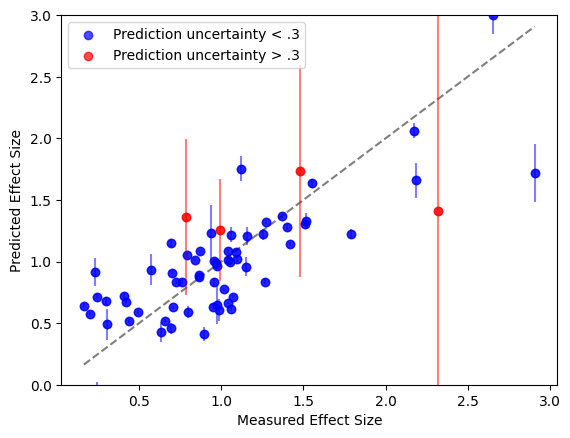

R^2: 0.656
Mean absolute error: 0.2670
-----
R^2 removing high uncertainty: 0.685
MAE removing high uncertainty: 0.2522


In [67]:
#up to thrid order
# #these will be input features for the model
data = codes_and_CIs[[ 'Lec', 'CG', 'WG',  'OG', 'SQ', ]].to_numpy()
#This is a linear regression model, but we use nonlinear terms by adding polynomila features
data = add_cross_terms_3(data)

keepers, AICs, good_fits = feature_selection(data, target, its=10000, n =1, prt = True, num_choose = 10)

LOO_predictions_mean, LOO_predictions_std, LOO_weights = bootstrap_LOO(data, target, keepers, good_fits, bootstrap_n=300)

LOO_plot(target, LOO_predictions_mean, LOO_predictions_std)

In [68]:
#up to second order terms

def add_cross_terms_2(data):
    ## this functions adds polynomial and cross terms to the data
        
    pts, features = data.shape
    #
    cross_factors = (data[:, :features].reshape(pts, 1, features) *data[:, :features].reshape(pts, features, 1))#.reshape(pts, features * features)
    #keep only upper triangle

    #second order terms
    cross_factors = cross_factors[:, np.triu_indices(features, k=1)[0], np.triu_indices(features, k=1)[1]]
    cross_factors = np.hstack((cross_factors, data**2))


    data = np.hstack((data, cross_factors))

    data = np.hstack((data, np.ones((data.shape[0], 1))))  # add bias term
    return data


Iteration 1 finished with AIC 78.1
Iteration 1001 finished with AIC 66.15
Iteration 2001 finished with AIC 91.21
Iteration 3001 finished with AIC 90.79
Iteration 4001 finished with AIC 74.97
Iteration 5001 finished with AIC 81.56
Iteration 6001 finished with AIC 73.24
Iteration 7001 finished with AIC 57.31
Iteration 8001 finished with AIC 59.76
Iteration 9001 finished with AIC 92.07


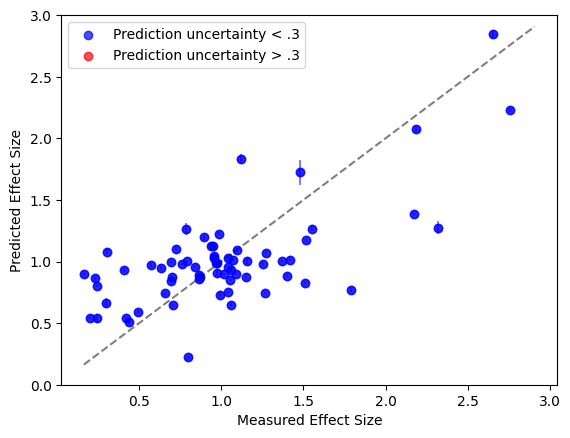

R^2: 0.574
Mean absolute error: 0.2959
-----
R^2 removing high uncertainty: 0.574
MAE removing high uncertainty: 0.2959


In [69]:
#add in PQ, up to second
# #these will be input features for the model
data = codes_and_CIs[[ 'Lec', 'CG', 'WG',  'OG', 'SQ', 'PQ' ]].to_numpy()
#This is a linear regression model, but we use nonlinear terms by adding polynomila features
data = add_cross_terms_2(data)

keepers, AICs, good_fits = feature_selection(data, target, its=10000, n =1, prt = True, num_choose = 10)

LOO_predictions_mean, LOO_predictions_std, LOO_weights = bootstrap_LOO(data, target, keepers, good_fits, bootstrap_n=300)

LOO_plot(target, LOO_predictions_mean, LOO_predictions_std)

Iteration 1 finished with AIC 69.19
Iteration 1001 finished with AIC 57.33
Iteration 2001 finished with AIC 69.83
Iteration 3001 finished with AIC 56.05
Iteration 4001 finished with AIC 60.89
Iteration 5001 finished with AIC 68.59
Iteration 6001 finished with AIC 66.35
Iteration 7001 finished with AIC 58.51
Iteration 8001 finished with AIC 77.98
Iteration 9001 finished with AIC 50.41


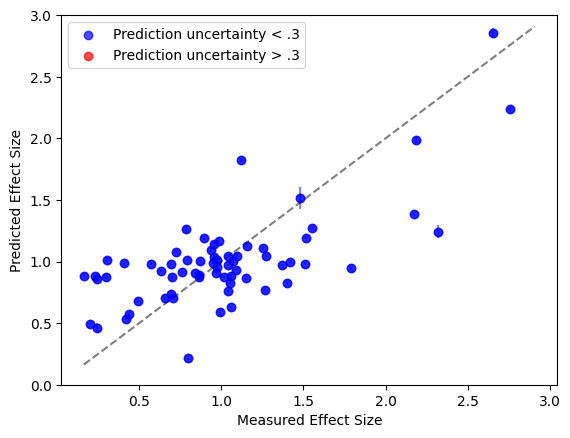

R^2: 0.583
Mean absolute error: 0.2911
-----
R^2 removing high uncertainty: 0.583
MAE removing high uncertainty: 0.2911


In [70]:
#up to second order
# #these will be input features for the model
data = codes_and_CIs[[ 'Lec', 'CG', 'WG',  'OG', 'SQ', ]].to_numpy()
#This is a linear regression model, but we use nonlinear terms by adding polynomila features
data = add_cross_terms_2(data)

keepers, AICs, good_fits = feature_selection(data, target, its=10000, n =1, prt = True, num_choose = 10)

LOO_predictions_mean, LOO_predictions_std, LOO_weights = bootstrap_LOO(data, target, keepers, good_fits, bootstrap_n=300)

LOO_plot(target, LOO_predictions_mean, LOO_predictions_std)

Iteration 1 finished with AIC 108.78
Iteration 1001 finished with AIC 108.39
Iteration 2001 finished with AIC 108.78
Iteration 3001 finished with AIC 108.78
Iteration 4001 finished with AIC 109.04
Iteration 5001 finished with AIC 109.64
Iteration 6001 finished with AIC 109.45
Iteration 7001 finished with AIC 108.78
Iteration 8001 finished with AIC 108.78
Iteration 9001 finished with AIC 107.19


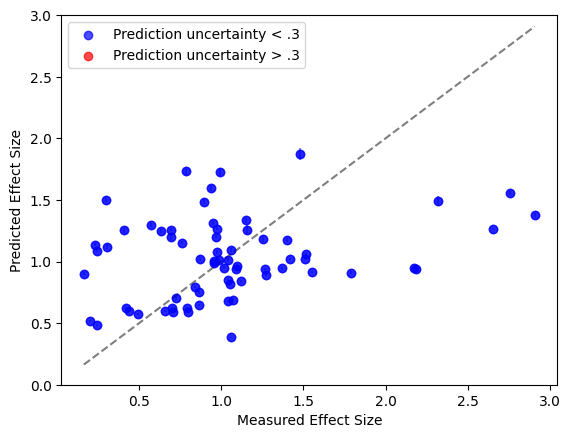

R^2: 0.089
Mean absolute error: 0.4372
-----
R^2 removing high uncertainty: 0.089
MAE removing high uncertainty: 0.4372


In [71]:
#first order
# #these will be input features for the model
data = codes_and_CIs[[ 'Lec', 'CG', 'WG',  'OG', 'SQ', ]].to_numpy()
#This is a linear regression model, but we use nonlinear terms by adding polynomila features
data = data

keepers, AICs, good_fits = feature_selection(data, target, its=10000, n =1, prt = True, num_choose = 10)

LOO_predictions_mean, LOO_predictions_std, LOO_weights = bootstrap_LOO(data, target, keepers, good_fits, bootstrap_n=300)

LOO_plot(target, LOO_predictions_mean, LOO_predictions_std)

In [72]:
#no 1st order terms, get rid of colinearity
def add_cross_terms_no1(data):
    ## this functions adds polynomial and cross terms to the data
        
    pts, features = data.shape
    #
    cross_factors = (data[:, :features].reshape(pts, 1, features) *data[:, :features].reshape(pts, features, 1))#.reshape(pts, features * features)
    #keep only upper triangle

    #second order terms
    cross_factors = cross_factors[:, np.triu_indices(features, k=1)[0], np.triu_indices(features, k=1)[1]]
    cross_factors = np.hstack((cross_factors, data**2))

    #third order terms
    cross_21 = (data.reshape(pts, 1, features)**2 * data.reshape(pts, features, 1))
    cross_12 = (data.reshape(pts, 1, features) * data.reshape(pts, features, 1)**2)


    cross_factors = np.hstack((cross_factors, cross_21[:, np.triu_indices(features, k=1)[0], np.triu_indices(features, k=1)[1]]))
    cross_factors = np.hstack((cross_factors, cross_12[:, np.triu_indices(features, k=1)[0], np.triu_indices(features, k=1)[1]]))

    data = np.hstack((cross_factors, data[:, :1]*data[:, 1:2]* data[:, 2:3]))  # interaction term for first three features
    if features >= 4:
        data = np.hstack((data, data[:, :1]*data[:, 1:2]* data[:, 3:4]))  # interaction term for first second and fourth features
        data = np.hstack((data, data[:, :1]*data[:, 2:3]* data[:, 3:4]))  # interaction term for first third and fourth features
        data = np.hstack((data, data[:, 1:2] * data[:, 2:3] * data[:, 3:4]))  # interaction term for second third and fourth features
    
    #######################
    if features >= 5:
        data = np.hstack((data, data[:, :1] * data[:, 1:2] * data[:, 4:5]))  # interaction term for first second and fifth features
        data = np.hstack((data, data[:, :1] * data[:, 2:3] * data[:, 4:5]))  # interaction term for first third and fifth features
        data = np.hstack((data, data[:, :1] * data[:, 3:4] * data[:, 4:5]))  # interaction term for first fourth and fifth features
        data = np.hstack((data, data[:, 1:2] * data[:,  2:3] * data[:, 4:5]))  # interaction term for second third and fifth features
        data = np.hstack((data, data[:, 1:2] * data[:, 3:4] * data[:, 4:5]))  # interaction term for second fourth and fifth features
        data = np.hstack((data, data[:, 2:3] * data[:, 3:4] * data[:, 4:5]))  # interaction term for third fourth and fifth features
        ########################
    data = np.hstack((data, data[:, :4]**3))  #third order terms

    
    #fourth order terms
    data = np.hstack((data, data[:, :4]**4))

    data = np.hstack((data, np.ones((data.shape[0], 1))))  # add bias term
    return data


Iteration 1 finished with AIC 73.63
Iteration 1001 finished with AIC 77.42
Iteration 2001 finished with AIC 134.23
Iteration 3001 finished with AIC 111.37
Iteration 4001 finished with AIC 83.31
Iteration 5001 finished with AIC 75.43
Iteration 6001 finished with AIC 179.38
Iteration 7001 finished with AIC 132.55
Iteration 8001 finished with AIC 132.13
Iteration 9001 finished with AIC 119.67


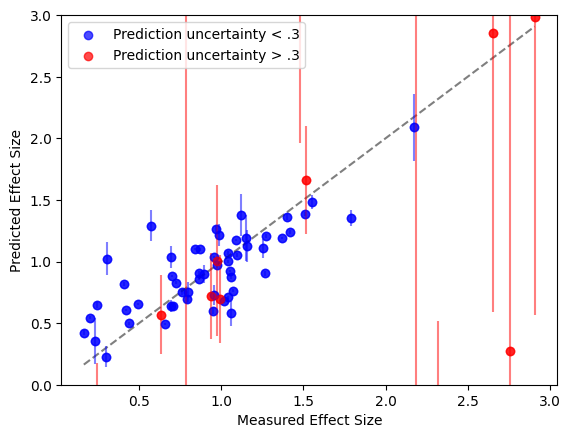

R^2: 0.240
Mean absolute error: 0.3720
-----
R^2 removing high uncertainty: 0.612
MAE removing high uncertainty: 0.1895


In [74]:
#no first order

#these will be input features for the model
data = codes_and_CIs[[ 'Lec', 'CG', 'WG', 'OG', 'SQ', ]].to_numpy()
#This is a linear regression model, but we use nonlinear terms by adding polynomila features
data = add_cross_terms_no1(data)

keepers, AICs, good_fits = feature_selection(data, target, its=10000, n =1, prt = True, num_choose = 10)

LOO_predictions_mean, LOO_predictions_std, LOO_weights = bootstrap_LOO(data, target, keepers, good_fits, bootstrap_n=300)

LOO_plot(target, LOO_predictions_mean, LOO_predictions_std)